In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各パス指定

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

# 分類数設定

In [3]:
NUM_CLASSES = 38


# 学習データ読み込み

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# モデル構築

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 42)                0         
                                                                 
 dense (Dense)               (None, 20)                860       
                                                                 
 dropout_1 (Dropout)         (None, 20)                0         
                                                                 
 dense_1 (Dense)             (None, 10)                210       
                                                                 
 dense_2 (Dense)             (None, 38)                418       
                                                                 
Total params: 1488 (5.81 KB)
Trainable params: 1488 (5.81 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000


46/47 [============================>.] - ETA: 0s - loss: 3.4658 - accuracy: 0.1242
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5


c:\Users\mohammed\ProjectStart\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


47/47 [==============================] - 13s 71ms/step - loss: 3.4658 - accuracy: 0.1240 - val_loss: 3.2043 - val_accuracy: 0.2692
Epoch 2/1000
45/47 [===========================>..] - ETA: 0s - loss: 2.8710 - accuracy: 0.2724
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
47/47 [==============================] - 2s 49ms/step - loss: 2.8632 - accuracy: 0.2732 - val_loss: 2.3519 - val_accuracy: 0.2819
Epoch 3/1000
47/47 [==============================] - ETA: 0s - loss: 2.1665 - accuracy: 0.3090
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
47/47 [==============================] - 3s 59ms/step - loss: 2.1665 - accuracy: 0.3090 - val_loss: 1.8348 - val_accuracy: 0.3985
Epoch 4/1000
45/47 [===========================>..] - ETA: 0s - loss: 1.8722 - accuracy: 0.3293
Epoch 4: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
47/47 [==============================] - 1s 32ms/step - loss: 1.8710 - accuracy: 0.3289 - val

In [ ]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

16/16 [==============================] - 0s 2ms/step - loss: 0.5966 - accuracy: 0.8280


In [ ]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [ ]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 87ms/step
[2.6805361e-03 1.4356810e-01 1.4798008e-01 1.6689419e-11 9.9280360e-18
 6.0377823e-04 2.2933880e-19 6.0223363e-02 2.3743415e-02 6.2120068e-01
 1.9369546e-16 6.4379771e-20 1.6504546e-19 8.4469554e-19 9.4636631e-22
 5.0921644e-18 3.4862007e-17 9.0654454e-18 4.2659841e-21 7.7170148e-20
 8.1901003e-19 2.7166708e-18 6.4642872e-19 1.5759815e-18 7.6434778e-20
 1.7940896e-18 7.6342773e-18 2.3463263e-17 1.9985656e-20 1.7240623e-19
 2.0774324e-22 2.4721772e-20 1.5664281e-17 1.1336908e-19 8.6974923e-18
 2.5463907e-15 1.4795660e-18 1.0532475e-18]
9


# 混同行列

62/62 [==============================] - 0s 2ms/step


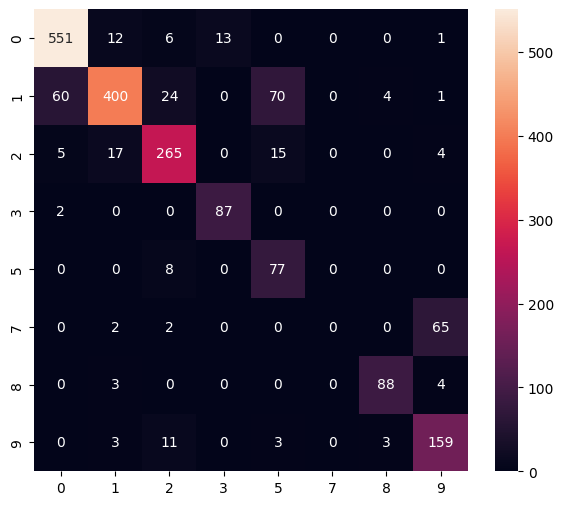

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       583
           1       0.92      0.72      0.80       559
           2       0.84      0.87      0.85       306
           3       0.87      0.98      0.92        89
           5       0.47      0.91      0.62        85
           7       0.00      0.00      0.00        69
           8       0.93      0.93      0.93        95
           9       0.68      0.89      0.77       179

    accuracy                           0.83      1965
   macro avg       0.70      0.78      0.73      1965
weighted avg       0.82      0.83      0.82      1965



c:\Users\mohammed\ProjectStart\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mohammed\ProjectStart\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mohammed\ProjectStart\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [ ]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)

c:\Users\mohammed\ProjectStart\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# モデルを変換(量子化)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\mohammed\AppData\Local\Temp\tmpl6ppnzbo\assets


INFO:tensorflow:Assets written to: C:\Users\mohammed\AppData\Local\Temp\tmpl6ppnzbo\assets


8120

# 推論テスト

In [ ]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [ ]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [ ]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [ ]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [ ]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[2.6805361e-03 1.4356801e-01 1.4797999e-01 1.6689457e-11 9.9280773e-18
 6.0377875e-04 2.2933885e-19 6.0223356e-02 2.3743421e-02 6.2120092e-01
 1.9369625e-16 6.4379784e-20 1.6504549e-19 8.4469895e-19 9.4636662e-22
 5.0922045e-18 3.4862020e-17 9.0655165e-18 4.2659853e-21 7.7170755e-20
 8.1901024e-19 2.7166716e-18 6.4642883e-19 1.5759878e-18 7.6435379e-20
 1.7940900e-18 7.6343088e-18 2.3463271e-17 1.9985815e-20 1.7240628e-19
 2.0774488e-22 2.4721968e-20 1.5664286e-17 1.1336911e-19 8.6975609e-18
 2.5463915e-15 1.4795720e-18 1.0532519e-18]
9
